In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [5]:
df = pd.read_csv(
        "https://huggingface.co/api/resolve-cache/datasets/scikit-learn/adult-census-income/fbeef6ec0e6fd88a5028b94683144000a6b380d5/adult.csv?%2Fdatasets%2Fscikit-learn%2Fadult-census-income%2Fresolve%2Fmain%2Fadult.csv=&etag=%225cf74ede1a6de37d85c96a61d30819a694dee749%22",
        engine="pyarrow",
        dtype_backend="pyarrow",
    )
print(df.head())
print(df.shape)
print(df.info())
print(df.head().to_string())

   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356              40  United-States  <=50K  
1          4356              18  United-States

In [6]:
print("Before cleaning: ", len(df))
df.replace("?", pd.NA, inplace=True)
df.dropna(inplace=True)
print("After cleaning: ", len(df))

Before cleaning:  32561
After cleaning:  30162


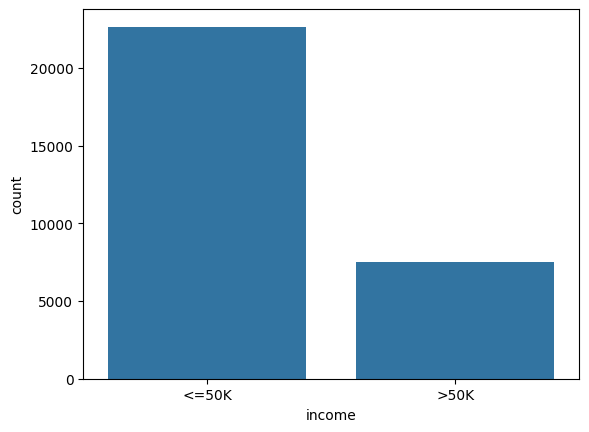

In [7]:
# Income Graph
sns.countplot(x="income", data=df)
plt.show()

In [8]:
# Education and Income Relationship
result = df.groupby("education")["income"].value_counts().unstack()
print(result)

income        <=50K  >50K
education                
10th            761    59
11th            989    59
12th            348    29
1st-4th         145     6
5th-6th         276    12
7th-8th         522    35
9th             430    25
Assoc-acdm      752   256
Assoc-voc       963   344
Bachelors      2918  2126
Doctorate        95   280
HS-grad        8223  1617
Masters         709   918
Preschool        45  <NA>
Prof-school     136   406
Some-college   5342  1336


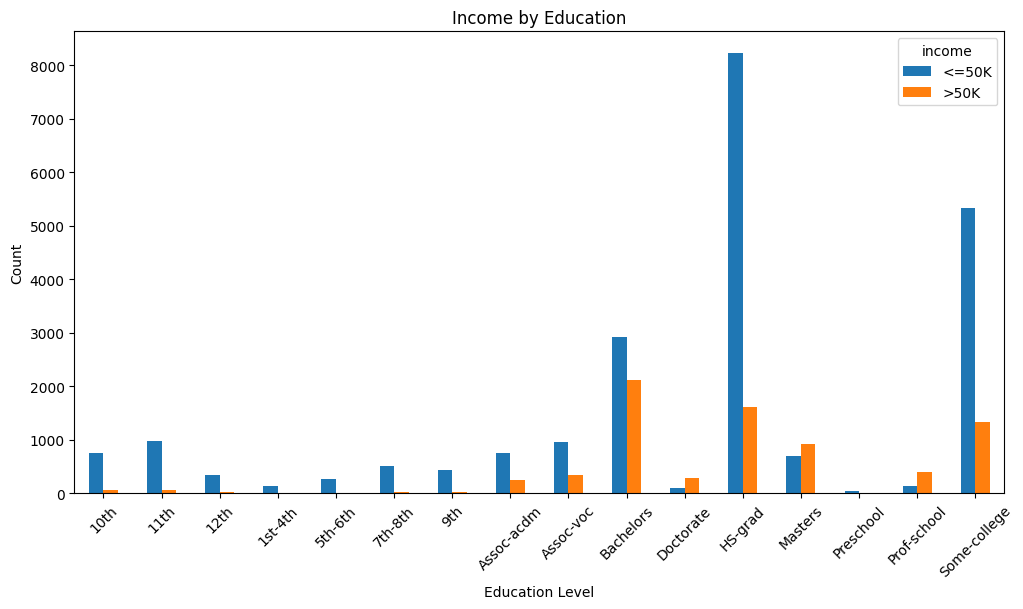

In [9]:
# Plot
result.plot(kind="bar", figsize=(12, 6))
# Labels and title
plt.title("Income by Education")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

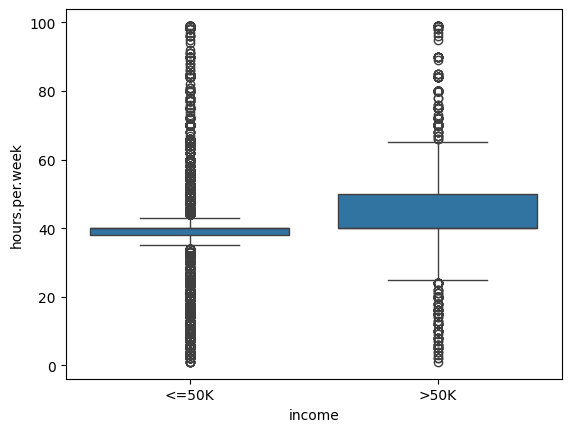

In [10]:
# Show graph
sns.boxplot(x="income", y="hours.per.week", data=df)
plt.show()

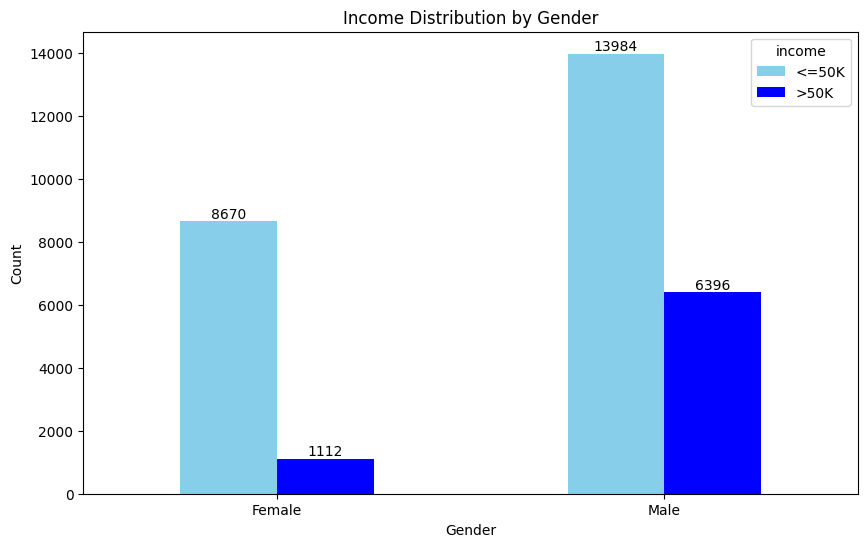

In [11]:
result = df.groupby("sex")["income"].value_counts().unstack()

# Plot with custom colors
ax = result.plot(
    kind="bar",
    figsize=(10,6),
    color=["skyblue", "blue"]
)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container)

# Titles and labels
plt.title("Income Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)

# Show graph
plt.show()

<ArrowExtensionArray>
[         'Private',        'State-gov',      'Federal-gov',
 'Self-emp-not-inc',     'Self-emp-inc',        'Local-gov',
      'Without-pay']
Length: 7, dtype: string[pyarrow]


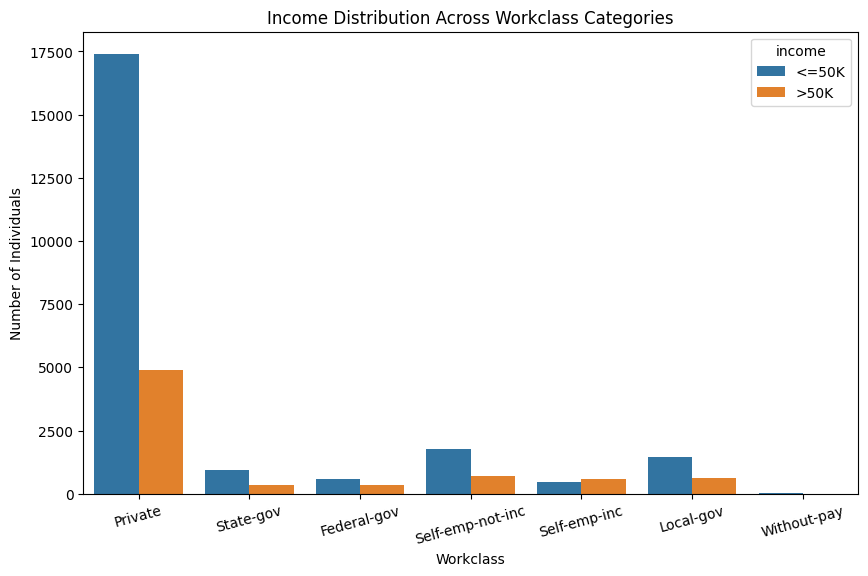

In [12]:
print(df["workclass"].unique())

# Select workclasses
top_workclasses = df["workclass"].value_counts().head(7).index

filtered_df = df[df["workclass"].isin(top_workclasses)]

# Create chart
plt.figure(figsize=(10,6))

sns.countplot(
    data=filtered_df,
    x="workclass",
    hue="income"
)

# Titles and labels
plt.title("Income Distribution Across Workclass Categories")
plt.xlabel("Workclass")
plt.ylabel("Number of Individuals")

plt.xticks(rotation=15)

plt.show()

In [13]:
result = df[df["income"] == ">50K"]["occupation"].value_counts().head(10)
print(result)

occupation
Exec-managerial      1937
Prof-specialty       1811
Sales                 970
Craft-repair          908
Adm-clerical          498
Transport-moving      319
Tech-support          278
Machine-op-inspct     245
Protective-serv       210
Other-service         132
Name: count, dtype: int64[pyarrow]


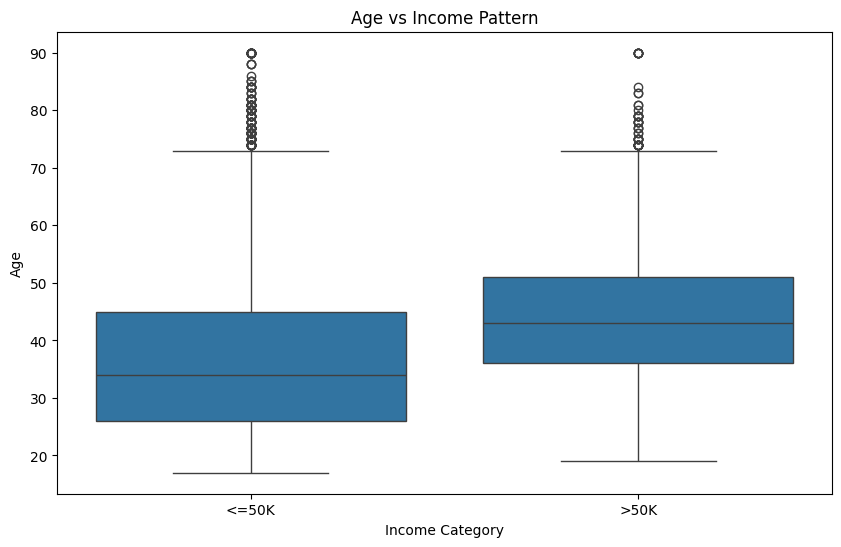

In [14]:
# Create figure
plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(
    x="income",
    y="age",
    data=df
)

# Titles and labels
plt.title("Age vs Income Pattern")
plt.xlabel("Income Category")
plt.ylabel("Age")

# Show graph
plt.show()